Name: Aditi Paudel
Group: L5CG1
Std no.: 2408635

1.1 Data Preparation

In [ ]:
import os
import zipfile

zip_path = "/content/drive/MyDrive/AI ML/week5/Copy of FruitinAmazon.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")
train_dir = "/content/dataset/FruitinAmazon/train"

#getting the class name/subdirectories
class_names = sorted(os.listdir(train_dir))

print("Dataset name: ",os.listdir("dataset"))

if not class_names:
  print("No class directories foiunf in the train folder!!")
else:
  print("Class names:",class_names)

Dataset extracted!
Dataset name:  ['FruitinAmazon']
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


1.2 Checking for corrupted images

In [ ]:
from PIL import Image, UnidentifiedImageError

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            with Image.open(img_path) as img:
                img.verify()
        except (IOError, UnidentifiedImageError):
            corrupted_images.append(img_path)

if corrupted_images:
    print("Corrupted Images Found:", corrupted_images)
else:
    print("No corrupted images found.")

No corrupted images found.


1.3 Checking class blance

In [ ]:
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('png','jpg','jpeg'))]
    class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("="*45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("="*45)


Class Distribution:
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


1.4 Visualization

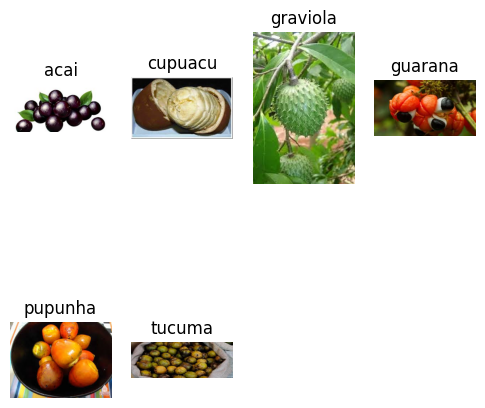

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = sorted(os.listdir(train_dir))

plt.figure(figsize=(6,6))
#this is to display one random image from each class
for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, (len(classes)//2)+1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

2. Data Generation and preprocessing

In [ ]:
import tensorflow as tf

img_height = 224
img_width = 224
batch_size = 32
validation_split = 0.2
#normalizing pixel values from 0-255 to 0-1
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
#loading validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
#applying normalization to datasets
train_ds = train_ds.map(lambda x,y:(rescale(x),y))
val_ds = val_ds.map(lambda x,y:(rescale(x),y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


2.1 Data Augmentation

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

2.2 Rescalling

In [ ]:
# Include rescaling inside model
rescale_layer = layers.Rescaling(1./255)

3. CNN model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Dropout, Dense, Flatten
from tensorflow.keras import layers

model = Sequential([

    # Data augmentation
    layers.Lambda(data_augmentation, input_shape=(224,224,3)),

    # Block 1
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 4
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Flatten
    Flatten(),

    # Fully connected layer
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    # Output layer
    Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 6,814,278 (25.99 MB)

 Trainable params: 6,813,062 (25.99 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

4. Tranning the model

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model during training
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Stop training if validation loss does not improve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.2176 - loss: 2.3737 
Epoch 1: val_loss improved from None to 1.50962, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 11s/step - accuracy: 0.2778 - loss: 2.1877 - val_accuracy: 0.2778 - val_loss: 1.5096
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6557 - loss: 0.9753  
Epoch 2: val_loss did not improve from 1.50962
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 8s/step - accuracy: 0.6389 - loss: 1.0444 - val_accuracy: 0.1111 - val_loss: 1.6857
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6059 - loss: 1.0905
Epoch 3: val_loss did not improve from 1.50962
3/3 ━━━━━━━━━━━━━━━━━━━━ 32s 7s/step - accuracy: 0.5833 - loss: 1.0945 - val_accuracy: 0.0000e+00 - val_loss: 2.6741
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6753 - loss: 0.9020
Epoch 4: val_loss did not improve from 1.50962
3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 6s/step - accuracy: 0.66

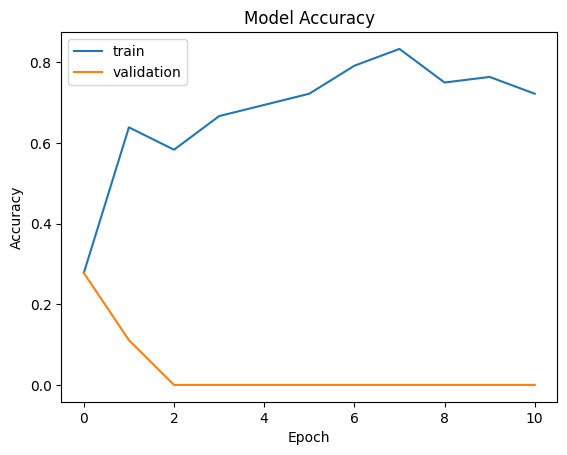

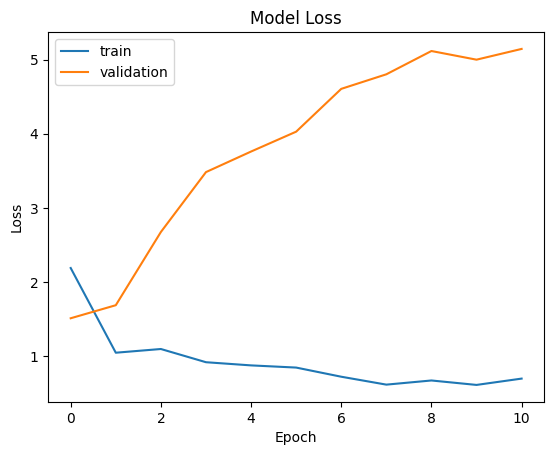

In [ ]:
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='validation')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='validation')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
test_loss,test_acc = model.evaluate(val_ds)

print("Test Accuracy:",test_acc)
print("Test Loss:",test_loss)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2778 - loss: 1.5096
Test Accuracy: 0.2777777910232544
Test Loss: 1.5096163749694824


In [ ]:
# Save the trained model
model.save("fruit_cnn_model.keras")

# Load the saved model
from tensorflow.keras.models import load_model
loaded_model = load_model("fruit_cnn_model.keras")

# Evaluate the loaded model
loss, accuracy = loaded_model.evaluate(val_ds)

print("Loaded Model Accuracy:", accuracy)
print("Loaded Model Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2778 - loss: 1.5096
Loaded Model Accuracy: 0.2777777910232544
Loaded Model Loss: 1.5096163749694824


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images,labels in val_ds:

    predictions = loaded_model.predict(images)

    pred_labels = np.argmax(predictions,axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)
unique_labels = np.unique(y_true)

print(classification_report(y_true,y_pred, labels=unique_labels,target_names=[classes[i] for i in unique_labels]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

     pupunha       0.00      0.00      0.00         3
      tucuma       0.62      0.33      0.43        15

   micro avg       0.62      0.28      0.38        18
   macro avg       0.31      0.17      0.22        18
weighted avg       0.52      0.28      0.36        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


5. Using VGG16

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

model_transfer = Sequential([

    base_model,

    Flatten(),

    Dense(256, activation='relu'),

    Dense(len(class_names), activation='softmax')
])

In [ ]:
model_transfer.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

6. Training the model

In [ ]:
history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 75s 25s/step - accuracy: 0.1111 - loss: 8.1055 - val_accuracy: 0.0000e+00 - val_loss: 24.3832
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 24s/step - accuracy: 0.2778 - loss: 10.0733 - val_accuracy: 0.1667 - val_loss: 10.2008
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 75s 20s/step - accuracy: 0.5417 - loss: 4.1851 - val_accuracy: 0.8333 - val_loss: 0.3008
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 20s/step - accuracy: 0.8333 - loss: 0.3964 - val_accuracy: 0.8333 - val_loss: 0.6517
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 63s 20s/step - accuracy: 0.7778 - loss: 0.7603 - val_accuracy: 0.8333 - val_loss: 0.5179
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 90s 25s/step - accuracy: 0.8472 - loss: 0.4621 - val_accuracy: 0.8889 - val_loss: 0.3938
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 24s/step - accuracy: 0.9583 - loss: 0.1040 - val_accuracy: 0.8333 - val_loss: 0.5829
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 75s 20s/step - accuracy: 0.9722 - loss: 0.0697 - val_accuracy: 0.8333 - val_loss: 

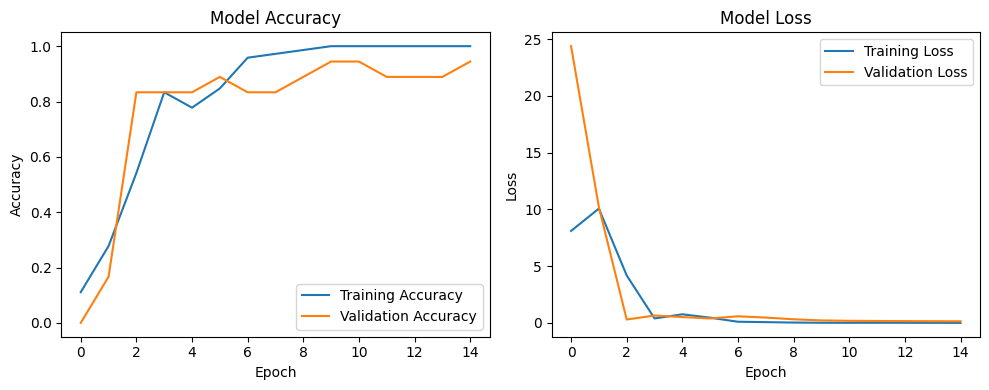

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
loss, accuracy = model_transfer.evaluate(val_ds)

print("Transfer Learning Accuracy:", accuracy)
print("Transfer Learning Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.9444 - loss: 0.1454
Transfer Learning Accuracy: 0.9444444179534912
Transfer Learning Loss: 0.14543594419956207


Adding fine tuning

In [ ]:
from tensorflow.keras.optimizers import RMSprop
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

model_transfer.compile(
    optimizer=RMSprop(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Training the fine tuned model

In [ ]:
history_finetune = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 65s 20s/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9444 - val_loss: 0.1460
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 24s/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9444 - val_loss: 0.1477
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 24s/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9444 - val_loss: 0.1502
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 24s/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9444 - val_loss: 0.1508
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 75s 20s/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9444 - val_loss: 0.1517
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 21s/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9444 - val_loss: 0.1525
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 25s/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9444 - val_loss: 0.1556
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 20s/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9444 - val_loss: 0.1556


Final evaluation

In [ ]:
loss, accuracy = model_transfer.evaluate(val_ds)

print("Fine-Tuned Model Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 0.9444 - loss: 0.1566
Fine-Tuned Model Accuracy: 0.9444444179534912
